In [1]:
# Plot BIAS CORRECTED Annual PM2.5
# MODEL COMPARISON

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter
from utils.utils import get_scenario_config

In [3]:
def load_pm25_bc_ensemble_members(model, scenario, config):
    # === Path config ===
    PM25_DIR = f"/glade/work/awells/air_quality/{model}/pm25/annual_pm25_bc/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Annual_PM25_BC_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(PM25_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_pm25_bc_for_plotting(model, scenario, config):
    """
    Calculate final decade and ensemble mean
    """

    # Load ensemble members
    da = load_pm25_bc_ensemble_members(model, scenario, config)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last year values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [15]:
def plot_pm25_bc(da, model, scenario, start_year, end_year, vmin, vmax, SAVE_DIR, land=False):
    # Create figure and layout
    fig = plt.figure(figsize=autosize_figure(1, 1, scale_factor=1.2))
    gs = GridSpec(2, 1, height_ratios=[15, 1])

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    if land is True:
        da = land_filter(da)

    # Plot map
    ax = fig.add_subplot(gs[0, 0], projection=projection)
    cb = da.plot(
        transform=crs,
        vmax=vmax,
        vmin=vmin,
        cmap="RdBu_r",
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Bias Corrected Annual PM2.5\n {model} {scenario} {start_year}-{end_year}", fontsize=14)

    # Colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("PM2.5 (µg/m³)", fontsize=13)

    plt.tight_layout()

    if land is True:
        out_file = f"PM25_BC_land_{model}_{scenario}_{start_year}-{end_year}.png"
    else:
        out_file = f"PM25_BC_{model}_{scenario}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

In [8]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised

SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/pm25/"

model = "CESM2"

scenario1 = "G6-1.5K"
scenario2 = "SSP245_G6"

scenario_name = f"{scenario1}-{scenario2}"

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1, first_year1, last_year1 = process_pm25_bc_for_plotting(model, scenario1, config1)
da2, first_year2, last_year2 = process_pm25_bc_for_plotting(model, scenario2, config2)

da = da1 - da2  # Check this is the way round you want it

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


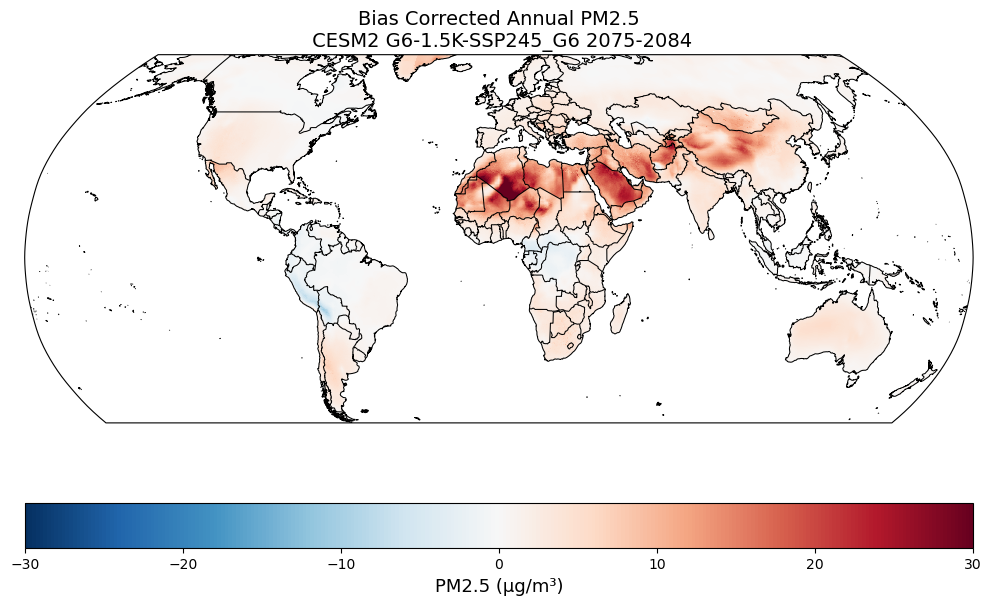

In [19]:
# For model comparison - adjust as necessary
vmin = -30
vmax = 30

# Plotting without ocean
plot_pm25_bc(da, model, scenario_name, first_year1, last_year1, vmin, vmax, SAVE_DIR, land=True)
# Plotting with ocean
# plot_pm25_bc(da, model, scenario_name, first_year2, last_year2, vmin, vmax, SAVE_DIR, land=False)